
## 概要
- 元サイト：SIGNATE
- ページ：[【練習問題】お弁当の需要予測](https://user.competition.signate.jp/ja/competition/detail/?competition=b2c7df3442d04e73bdbab95b1dd6f91d&task=4265b59bdd9d4b47af2771fe82dc9b52&tab=dataset&leaderboard=public)
- 参加期間：20250928-


In [59]:
# 必要なライブラリのインストール
%pip install lightgbm scikit-optimize optuna japanize-matplotlib -q

print("ライブラリのインストールが完了しました")


Note: you may need to restart the kernel to use updated packages.
ライブラリのインストールが完了しました


In [ ]:
# ライブラリのインポート
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
import datetime as dt

# Jupyter環境でのみマジックコマンドを有効化
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# ハイパーパラメータ調整用
try:
    import lightgbm as lgb
except OSError as e:
    print("LightGBMのインポート時にエラーが発生しました:", e)
    lgb = None

try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
except ImportError as e:
    print("scikit-optimizeのインポート時にエラーが発生しました:", e)
    BayesSearchCV = None

import time

print("✓ すべてのライブラリのインポートが完了しました")


✓ すべてのライブラリのインポートが完了しました


In [61]:
timestamp = dt.datetime.now().strftime("%Y%m%d%H%M%S")
timestamp

'20250927143246'

## 1. データの読み込みと基本確認


In [62]:
# データの読み込み
train = pd.read_csv('/workspaces/competition/data/input/20250928/train.csv')
test = pd.read_csv('/workspaces/competition/data/input/20250928/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {list(train.columns)}")
print(f"Test columns: {list(test.columns)}")


Train shape: (207, 12)
Test shape: (40, 11)

Train columns: ['datetime', 'y', 'week', 'soldout', 'name', 'kcal', 'remarks', 'event', 'payday', 'weather', 'precipitation', 'temperature']
Test columns: ['datetime', 'week', 'soldout', 'name', 'kcal', 'remarks', 'event', 'payday', 'weather', 'precipitation', 'temperature']


In [63]:
#  全行表示 or 一部表示
# ⭐️不要なブロックをコメントアウトして使用

# # 表示オプションの設定
# pd.set_option('display.max_colwidth', None)  # 列の最大幅を無制限に
# pd.set_option('display.max_columns', None)   # 表示する最大列数を無制限に
# pd.set_option('display.max_rows', None)      # 表示する最大行数を無制限に（注意：大量データの場合）
# pd.set_option('display.width', None)         # 表示幅を無制限に



# 表示設定を元に戻す（必要に応じて）
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [64]:
train

,datetime,y,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature
0,2013-11-18,90,月,0,厚切りイカフライ,NaN,NaN,NaN,NaN,快晴,--,19.8
1,2013-11-19,101,火,1,手作りヒレカツ,NaN,NaN,NaN,NaN,快晴,--,17.0
2,2013-11-20,118,水,0,白身魚唐揚げ野菜あん,NaN,NaN,NaN,NaN,快晴,--,15.5
3,2013-11-21,120,木,1,若鶏ピリ辛焼,NaN,NaN,NaN,NaN,快晴,--,15.2
4,2013-11-22,130,金,1,ビッグメンチカツ,NaN,NaN,NaN,NaN,快晴,--,16.1
...,...,...,...,...,...,...,...,...,...,...,...,...
202,2014-9-24,59,水,1,白身魚のマスタード焼き,408.0,NaN,NaN,NaN,曇,0,24.8
203,2014-9-25,50,木,0,牛カルビ焼き肉,394.0,NaN,NaN,NaN,曇,0,25.4
204,2014-9-26,45,金,0,ランチビュッフェ,NaN,スペシャルメニュー（800円）,キャリアアップ支援セミナー,NaN,晴れ,--,27.1
205,2014-9-29,56,月,1,豚肉と玉子の炒め,404.0,NaN,NaN,NaN,快晴,--,26.6


In [65]:
# trainとtestのpaydayカラムのNaNを0に置換
train['payday'] = train['payday'].fillna(0)
test['payday'] = test['payday'].fillna(0)


In [66]:
# 基本統計の確認
print("=== Train Data Info ===")
print(train.info())
print("\n=== Test Data Info ===")
print(test.info())

print("\n=== Train Data Head ===")
display(train.head())
print("\n=== Test Data Head ===")
display(test.head())


=== Train Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       207 non-null    object 
 1   y              207 non-null    int64  
 2   week           207 non-null    object 
 3   soldout        207 non-null    int64  
 4   name           207 non-null    object 
 5   kcal           166 non-null    float64
 6   remarks        21 non-null     object 
 7   event          14 non-null     object 
 8   payday         207 non-null    float64
 9   weather        207 non-null    object 
 10  precipitation  207 non-null    object 
 11  temperature    207 non-null    float64
dtypes: float64(3), int64(2), object(7)
memory usage: 19.5+ KB
None

=== Test Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------     

,datetime,y,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature
0,2013-11-18,90,月,0,厚切りイカフライ,NaN,NaN,NaN,0.0,快晴,--,19.8
1,2013-11-19,101,火,1,手作りヒレカツ,NaN,NaN,NaN,0.0,快晴,--,17.0
2,2013-11-20,118,水,0,白身魚唐揚げ野菜あん,NaN,NaN,NaN,0.0,快晴,--,15.5
3,2013-11-21,120,木,1,若鶏ピリ辛焼,NaN,NaN,NaN,0.0,快晴,--,15.2
4,2013-11-22,130,金,1,ビッグメンチカツ,NaN,NaN,NaN,0.0,快晴,--,16.1



=== Test Data Head ===


,datetime,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature
0,2014-10-1,水,1,メンチカツ,420.0,NaN,NaN,0.0,雨,0,20.2
1,2014-10-2,木,0,バーベキューチキン,415.0,NaN,NaN,0.0,曇,--,23.9
2,2014-10-3,金,0,豚肉のマスタード焼き,405.0,NaN,NaN,0.0,晴れ,--,28.7
3,2014-10-6,月,1,麻婆春雨,400.0,NaN,NaN,0.0,雨,0.5,21.5
4,2014-10-7,火,0,厚揚げ肉みそ炒め,430.0,NaN,NaN,0.0,晴れ,--,22.1


In [67]:
# 欠損値とunknownデータの確認
print("=== Train Data Missing Values ===")
print(train.isnull().sum())
print("\n=== Test Data Missing Values ===")
print(test.isnull().sum())

# unknownデータの確認
print("\n=== Unknown Data in Train ===")
for col in train.select_dtypes(include=['object']).columns:
    unknown_count = (train[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}件 ({unknown_count/len(train)*100:.2f}%)")

print("\n=== Unknown Data in Test ===")
for col in test.select_dtypes(include=['object']).columns:
    unknown_count = (test[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}件 ({unknown_count/len(test)*100:.2f}%)")


=== Train Data Missing Values ===
datetime           0
y                  0
week               0
soldout            0
name               0
kcal              41
remarks          186
event            193
payday             0
weather            0
precipitation      0
temperature        0
dtype: int64

=== Test Data Missing Values ===
datetime          0
week              0
soldout           0
name              0
kcal              4
remarks          33
event            37
payday            0
weather           0
precipitation     0
temperature       0
dtype: int64

=== Unknown Data in Train ===

=== Unknown Data in Test ===


## 2. 探索的データ分析（EDA）


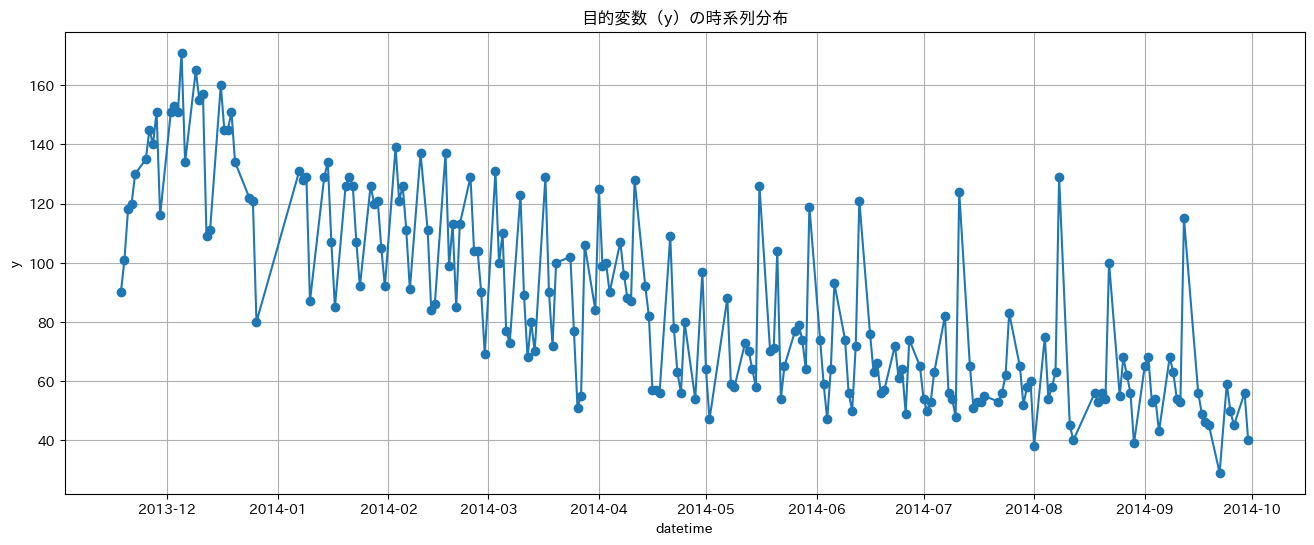

In [68]:
# 目的変数（y）の時系列分布を可視化
import matplotlib.pyplot as plt

# datetime列をdatetime型に変換（必要なら）
if not np.issubdtype(train['datetime'].dtype, np.datetime64):
    train['datetime'] = pd.to_datetime(train['datetime'])

plt.figure(figsize=(16, 6))
plt.plot(train['datetime'], train['y'], marker='o', linestyle='-')
plt.xlabel('datetime')
plt.ylabel('y')
plt.title('目的変数（y）の時系列分布')
plt.grid(True)
plt.show()



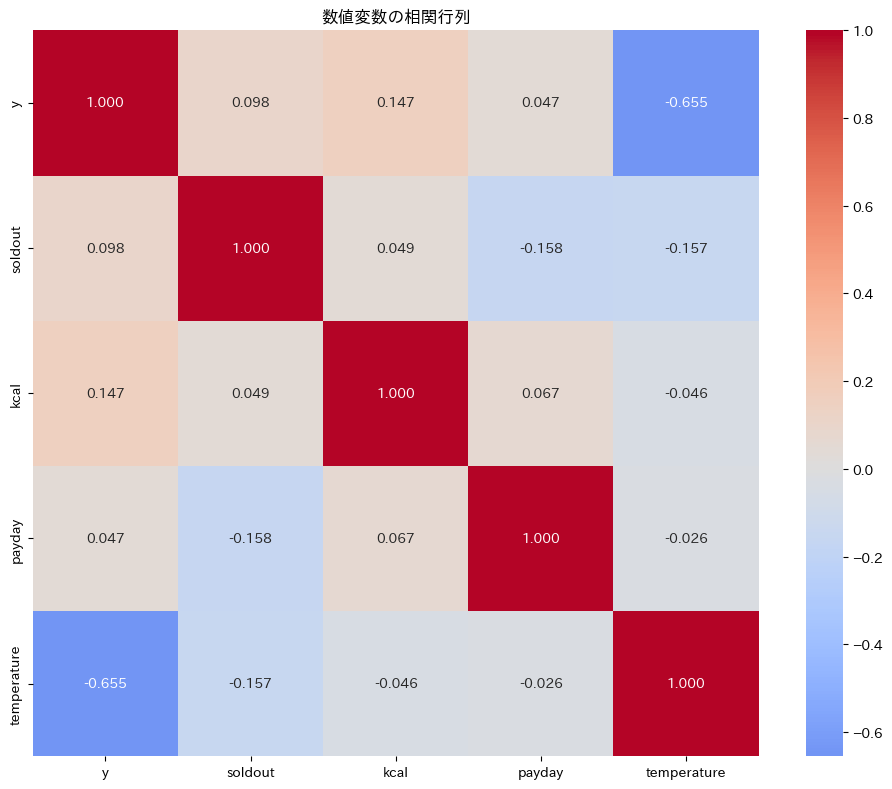

目的変数との相関係数（絶対値）:
temperature    0.655332
kcal           0.147269
soldout        0.098308
payday         0.046546
Name: y, dtype: float64


In [69]:
# 数値変数の相関分析
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation_matrix = train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f')
plt.title('数値変数の相関行列')
plt.tight_layout()
plt.show()

# 目的変数との相関
y_correlations = correlation_matrix['y'].drop('y').abs().sort_values(ascending=False)
print("目的変数との相関係数（絶対値）:")
print(y_correlations)


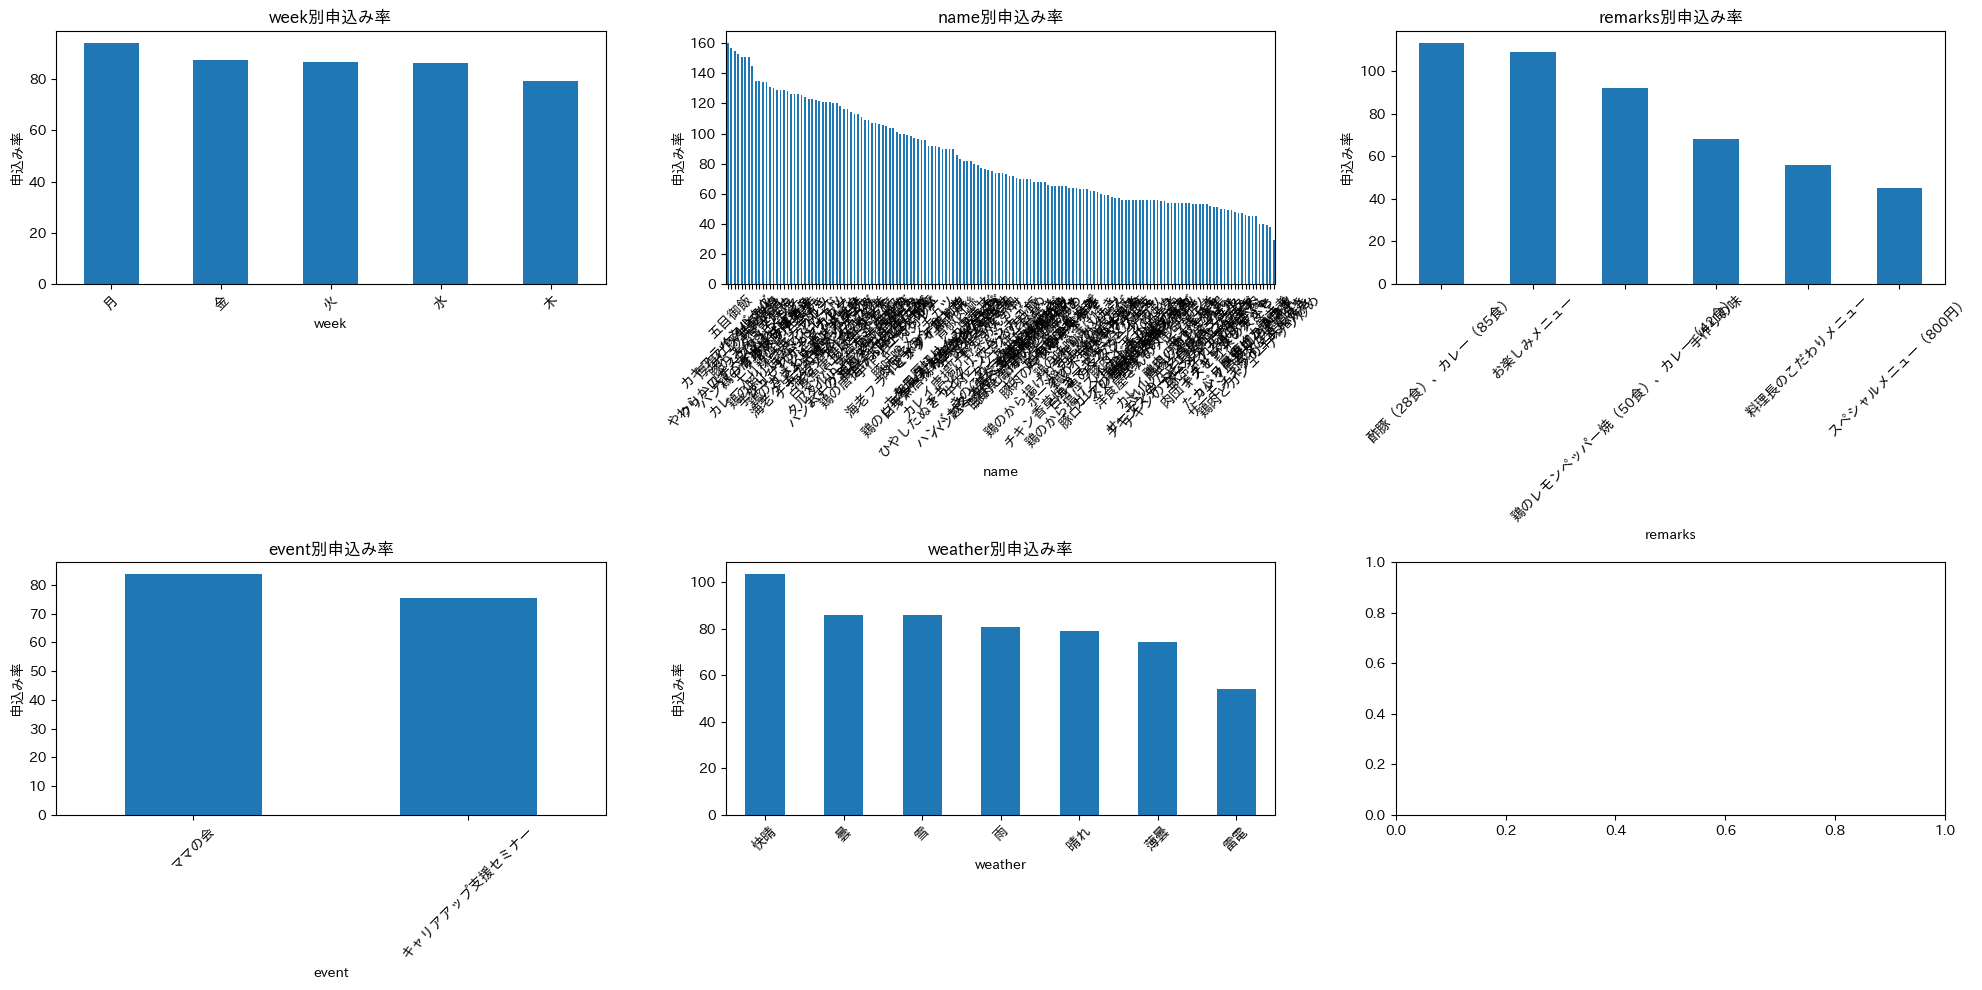

In [70]:
# カテゴリ変数と目的変数の関係
categorical_cols = ['week', 'name', 'remarks', 'event', 'weather']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in train.columns:
        # 申込み率を計算
        conversion_rate = train.groupby(col)['y'].mean().sort_values(ascending=False)
        
        # プロット
        conversion_rate.plot.bar(ax=axes[i])
        axes[i].set_title(f'{col}別申込み率')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('申込み率')

plt.tight_layout()
plt.show()


## 3. 特徴量エンジニアリング


In [71]:
# 特徴量エンジニアリング用のデータコピー
train_fe = train.copy()
test_fe = test.copy()

print("特徴量エンジニアリングを開始します...")

# 1. 日付から曜日・月・年を抽出
train_fe['datetime'] = pd.to_datetime(train_fe['datetime'])
test_fe['datetime'] = pd.to_datetime(test_fe['datetime'])

train_fe['year'] = train_fe['datetime'].dt.year
test_fe['year'] = test_fe['datetime'].dt.year

train_fe['month'] = train_fe['datetime'].dt.month
test_fe['month'] = test_fe['datetime'].dt.month

train_fe['dayofweek'] = train_fe['datetime'].dt.dayofweek
test_fe['dayofweek'] = test_fe['datetime'].dt.dayofweek

print("✓ 日付特徴量の抽出完了")

# 2. 直前営業日との売上差分（時系列特徴量）
train_fe = train_fe.sort_values('datetime')
train_fe['y_diff'] = train_fe['y'].diff().fillna(0)
# テストデータには目的変数がないため、ダミーで0を入れる
test_fe['y_diff'] = 0
print("✓ 売上差分特徴量作成完了")

# 3. 連続売り切れ日数（soldoutの連続日数）
def calc_soldout_streak(soldout_series):
    streak = 0
    streaks = []
    for val in soldout_series:
        if val == 1:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    return streaks

train_fe['soldout_streak'] = calc_soldout_streak(train_fe['soldout'])
# テストデータは直前のtrainのsoldoutの最後の値を引き継ぐ必要があるが、ここでは0で初期化
test_fe['soldout_streak'] = 0
print("✓ 連続売り切れ日数特徴量作成完了")

# 4. 気温のカテゴリ化
def categorize_temperature(temp):
    try:
        temp = float(temp)
    except:
        return 'unknown'
    if temp < 15:
        return 'cold'
    elif temp < 25:
        return 'normal'
    else:
        return 'hot'

train_fe['temp_category'] = train_fe['temperature'].apply(categorize_temperature)
test_fe['temp_category'] = test_fe['temperature'].apply(categorize_temperature)
print("✓ 気温カテゴリ化完了")

# 5. イベント・給料日フラグ
train_fe['is_event'] = train_fe['event'].notnull().astype(int)
test_fe['is_event'] = test_fe['event'].notnull().astype(int)

train_fe['is_payday'] = (train_fe['payday'] == 1).astype(int)
test_fe['is_payday'] = (test_fe['payday'] == 1).astype(int)
print("✓ イベント・給料日フラグ作成完了")

# 6. メニュー名の一部特徴量化（例：揚げ物/カツ/魚/鶏などのワードを含むか）
def menu_keyword_flag(name, keywords):
    if pd.isnull(name):
        return 0
    for kw in keywords:
        if kw in name:
            return 1
    return 0

keywords = ['カツ', '唐揚', '魚', '鶏', '豚', '牛', 'フライ', '焼', '煮', '炒め', 'カレー']
for kw in keywords:
    train_fe[f'has_{kw}'] = train_fe['name'].apply(lambda x: menu_keyword_flag(x, [kw]))
    test_fe[f'has_{kw}'] = test_fe['name'].apply(lambda x: menu_keyword_flag(x, [kw]))
print("✓ メニュー名キーワード特徴量作成完了")

print(f"\n特徴量エンジニアリング完了 - Train: {train_fe.shape}, Test: {test_fe.shape}")


特徴量エンジニアリングを開始します...
✓ 日付特徴量の抽出完了
✓ 売上差分特徴量作成完了
✓ 連続売り切れ日数特徴量作成完了
✓ 気温カテゴリ化完了
✓ イベント・給料日フラグ作成完了
✓ メニュー名キーワード特徴量作成完了

特徴量エンジニアリング完了 - Train: (207, 31), Test: (40, 30)


In [72]:
# 4. 複合特徴量の作成（今回の特徴量に合わせて）

# 気温カテゴリと天気の複合特徴量
train_fe['temp_weather'] = train_fe['temp_category'] + '_' + train_fe['weather'].astype(str)
test_fe['temp_weather'] = test_fe['temp_category'] + '_' + test_fe['weather'].astype(str)
print("✓ 気温カテゴリ×天気の複合特徴量作成完了")

# メニュー名キーワード（例：カツ）と曜日の複合特徴量
train_fe['katsu_week'] = train_fe['has_カツ'].astype(str) + '_' + train_fe['week'].astype(str)
test_fe['katsu_week'] = test_fe['has_カツ'].astype(str) + '_' + test_fe['week'].astype(str)
print("✓ カツ×曜日の複合特徴量作成完了")

# イベント・給料日フラグの複合特徴量
train_fe['event_payday'] = train_fe['is_event'].astype(str) + '_' + train_fe['is_payday'].astype(str)
test_fe['event_payday'] = test_fe['is_event'].astype(str) + '_' + test_fe['is_payday'].astype(str)
print("✓ イベント×給料日の複合特徴量作成完了")

# 5. 数値特徴量の変換（今回の特徴量に合わせて）

# 気温の2乗項
train_fe['temperature_squared'] = train_fe['temperature'].astype(float) ** 2
test_fe['temperature_squared'] = test_fe['temperature'].astype(float) ** 2
print("✓ 気温の2乗項作成完了")

# kcalの対数変換（NaNはそのまま）
train_fe['kcal_log'] = np.log1p(train_fe['kcal'])
test_fe['kcal_log'] = np.log1p(test_fe['kcal'])
print("✓ kcalの対数変換完了")

print(f"\n特徴量エンジニアリング完了 - Train: {train_fe.shape}, Test: {test_fe.shape}")


✓ 気温カテゴリ×天気の複合特徴量作成完了
✓ カツ×曜日の複合特徴量作成完了
✓ イベント×給料日の複合特徴量作成完了
✓ 気温の2乗項作成完了
✓ kcalの対数変換完了

特徴量エンジニアリング完了 - Train: (207, 36), Test: (40, 35)


## 4. データの前処理


In [73]:
# 今回のデータに合わせて欠損値（NaN）を補完
train_processed = train_fe.copy()
test_processed = test_fe.copy()

print("欠損値の補完を開始します...")

# 今回のデータで欠損値が存在する主なカラム例
fillna_columns = ['kcal', 'remarks', 'event', 'weather', 'precipitation', 'temperature']

for col in fillna_columns:
    if col in train_processed.columns:
        # 数値型の場合は中央値、それ以外は最頻値で補完
        if train_processed[col].dtype.kind in 'biufc':  # 数値型
            fill_value = train_processed[col].median()
        else:
            fill_value = train_processed[col].mode()[0]
        
        train_nan_count = train_processed[col].isna().sum()
        test_nan_count = test_processed[col].isna().sum()
        
        train_processed[col] = train_processed[col].fillna(fill_value)
        test_processed[col] = test_processed[col].fillna(fill_value)
        
        print(f"{col}: train {train_nan_count}件, test {test_nan_count}件 → {fill_value}で補完")

print("\n✓ 欠損値の補完が完了しました")


欠損値の補完を開始します...
kcal: train 41件, test 4件 → 408.5で補完
remarks: train 186件, test 33件 → お楽しみメニューで補完
event: train 193件, test 37件 → ママの会で補完
weather: train 0件, test 0件 → 快晴で補完
precipitation: train 0件, test 0件 → --で補完
temperature: train 0件, test 0件 → 19.8で補完

✓ 欠損値の補完が完了しました


In [74]:
# 特徴量選択（今回のデータ用に更新）
# 目的変数以外の特徴量を選択（datetimeとyを除く）
exclude_columns = ['datetime', 'y']
use_columns = [col for col in train_processed.columns if col not in exclude_columns]

y = train_processed['y']
X_train = train_processed[use_columns]
X_test = test_processed[use_columns]

print(f"使用特徴量数: {len(use_columns)}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\n使用特徴量一覧:")
for i, col in enumerate(use_columns, 1):
    print(f"{i:2d}. {col}")


使用特徴量数: 34
Train shape: (207, 34)
Test shape: (40, 34)

使用特徴量一覧:
 1. week
 2. soldout
 3. name
 4. kcal
 5. remarks
 6. event
 7. payday
 8. weather
 9. precipitation
10. temperature
11. year
12. month
13. dayofweek
14. y_diff
15. soldout_streak
16. temp_category
17. is_event
18. is_payday
19. has_カツ
20. has_唐揚
21. has_魚
22. has_鶏
23. has_豚
24. has_牛
25. has_フライ
26. has_焼
27. has_煮
28. has_炒め
29. has_カレー
30. temp_weather
31. katsu_week
32. event_payday
33. temperature_squared
34. kcal_log


In [ ]:
# ダミー変数化（カテゴリ変数を数値に変換）
print("ダミー変数化を実行中...")
X_train_dummy = pd.get_dummies(X_train, drop_first=True)
X_test_dummy = pd.get_dummies(X_test, drop_first=True)

# 列の整合性を確保（テストデータにないカテゴリを0で埋める）
missing_cols = set(X_train_dummy.columns) - set(X_test_dummy.columns)
for col in missing_cols:
    X_test_dummy[col] = 0

# 列の順序を統一（訓練データと同じ順序にする）
X_test_dummy = X_test_dummy[X_train_dummy.columns]

print(f"✓ ダミー変数化完了")
print(f"Train: {X_train_dummy.shape}, Test: {X_test_dummy.shape}")
print(f"最終特徴量数: {X_train_dummy.shape[1]}")


ダミー変数化を実行中...
✓ ダミー変数化完了
Train: (207, 231), Test: (40, 231)
最終特徴量数: 231


## 5. ベースラインモデル（ロジスティック回帰）


In [ ]:
# データの分割（stratifyでエラーが出る場合はstratifyなしで分割）
try:
    X_train_split, X_valid_split, y_train_split, y_valid_split = train_test_split(
        X_train_dummy, y, test_size=0.2, random_state=82, stratify=y
    )
except ValueError as e:
    print(f"stratify指定でエラー発生: {e}\nstratifyなしで再実行します。")
    X_train_split, X_valid_split, y_train_split, y_valid_split = train_test_split(
        X_train_dummy, y, test_size=0.2, random_state=82
    )

print(f"データ分割完了 - Train: {X_train_split.shape}, Valid: {X_valid_split.shape}")


stratify指定でエラー発生: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
stratifyなしで再実行します。
データ分割完了 - Train: (165, 231), Valid: (42, 231)


In [ ]:
# 線形回帰（ベースライン）
print("線形回帰モデルを学習中...")

# 必要なライブラリをインポート
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 欠損値の補完（ダミー変数化後でもNaNが残る可能性があるため）
imputer = SimpleImputer(strategy='mean')
X_train_split_imp = imputer.fit_transform(X_train_split)
X_valid_split_imp = imputer.transform(X_valid_split)

# 線形回帰モデルの学習
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_split_imp, y_train_split)

# 予測
train_pred_lr = lr_baseline.predict(X_train_split_imp)
valid_pred_lr = lr_baseline.predict(X_valid_split_imp)

# 評価指標計算
train_mse_lr = mean_squared_error(y_train_split, train_pred_lr)
valid_mse_lr = mean_squared_error(y_valid_split, valid_pred_lr)
train_r2_lr = r2_score(y_train_split, train_pred_lr)
valid_r2_lr = r2_score(y_valid_split, valid_pred_lr)
train_mae_lr = mean_absolute_error(y_train_split, train_pred_lr)
valid_mae_lr = mean_absolute_error(y_valid_split, valid_pred_lr)

print("=== 線形回帰（ベースライン）===")
print(f"Train MSE: {train_mse_lr:.4f}")
print(f"Valid MSE: {valid_mse_lr:.4f}")
print(f"Train R²: {train_r2_lr:.4f}")
print(f"Valid R²: {valid_r2_lr:.4f}")
print(f"Train MAE: {train_mae_lr:.4f}")
print(f"Valid MAE: {valid_mae_lr:.4f}")


線形回帰モデルを学習中...
=== 線形回帰（ベースライン）===
Train MSE: 2.5481
Valid MSE: 9090.0231
Train R²: 0.9976
Valid R²: -6.7464
Train MAE: 0.6415
Valid MAE: 61.5966


## 6. LightGBM + ベイズ最適化


In [78]:
# LightGBMのlibgomp.so.1エラー対策
# Google Colabや一部のLinux環境ではlibgomp.so.1が必要です。未インストールの場合は下記でインストールしてください。
import os
import sys

def install_libgomp():
    try:
        # Ubuntu/Debian系
        if os.system("apt-get --version") == 0:
            print("libgomp1をインストールします...")
            os.system("apt-get update")
            os.system("apt-get install -y libgomp1")
        # RedHat/CentOS系
        elif os.system("yum --version") == 0:
            print("libgompをインストールします...")
            os.system("yum install -y libgomp")
        else:
            print("libgompの自動インストールに未対応の環境です。手動でlibgomp.so.1をインストールしてください。")
    except Exception as e:
        print("libgompインストール時にエラー:", e)

# libgomp.so.1が存在しない場合のみインストール
if not os.path.exists("/usr/lib/x86_64-linux-gnu/libgomp.so.1") and not os.path.exists("/usr/lib64/libgomp.so.1"):
    install_libgomp()

# 必要なライブラリのインポート
from skopt.space import Integer, Real
from lightgbm import LGBMRegressor

# LightGBMのパラメータ空間を定義
lgb_param_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'num_leaves': Integer(10, 200),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'reg_alpha': Real(0.0, 5.0),
    'reg_lambda': Real(0.0, 5.0),
    'min_child_samples': Integer(10, 50),
    'min_child_weight': Real(0.001, 5.0, prior='log-uniform')
}

# LightGBMモデルの初期化
lgb_model = LGBMRegressor(
    random_state=82,
    verbose=-1,
    n_jobs=-1
)

print("LightGBMのパラメータ空間を定義しました")


libgomp1をインストールします...
apt 3.0.3 (arm64)
Supported modules:
*Ver: Standard .deb
*Pkg:  Debian dpkg interface (Priority 30)
 Pkg:  Debian APT solver interface (Priority -1000)
 Pkg:  Debian APT planner interface (Priority -1000)
 S.L: 'deb' Debian binary tree
 S.L: 'deb-src' Debian source tree
 Idx: Debian Source Index
 Idx: Debian Package Index
 Idx: Debian Translation Index
 Idx: Debian dpkg status file
 Idx: Debian deb file
 Idx: Debian dsc file
 Idx: Debian control file
 Idx: EDSP scenario file
 Idx: EIPP scenario file
Hit:1 http://deb.debian.org/debian trixie InRelease
Hit:2 http://deb.debian.org/debian trixie-updates InRelease
Get:3 http://deb.debian.org/debian-security trixie-security InRelease [43.4 kB]
Fetched 43.4 kB in 0s (219 kB/s)
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
libgomp1 is already the newest version (14.2.0-19).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
LightGBMのパラメータ空間を定義しました


In [79]:
# ベイズ最適化の実行
print("ベイズ最適化を開始します（10回の試行）...")
start_time = time.time()

# データの前処理（欠損値補完）
imputer_lgb = SimpleImputer(strategy='mean')
X_train_split_lgb = imputer_lgb.fit_transform(X_train_split)
X_valid_split_lgb = imputer_lgb.transform(X_valid_split)

try:
    bayes_search = BayesSearchCV(
        lgb_model,
        lgb_param_space,
        n_iter=10,  # 10回の試行（データが少ないため）
        cv=3,       # 3-fold CV
        scoring='neg_mean_squared_error',  # 回帰用のスコアリング
        random_state=82,
        n_jobs=1,   # 並列処理を制限
        verbose=1
    )

    bayes_search.fit(X_train_split_lgb, y_train_split)

    end_time = time.time()
    print(f"\n✓ ベイズ最適化完了: {end_time - start_time:.2f}秒")

    # 最適なパラメータを表示
    print("\n=== 最適なパラメータ ===")
    best_params = bayes_search.best_params_
    for param, value in best_params.items():
        print(f"{param}: {value}")

    print(f"\n最良のCVスコア: {-bayes_search.best_score_:.4f} (MSE)")
    
except Exception as e:
    print(f"ベイズ最適化でエラーが発生: {e}")
    print("デフォルトパラメータでLightGBMを実行します...")
    best_params = {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'num_leaves': 31,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'min_child_samples': 20,
        'min_child_weight': 0.001
    }
    bayes_search = None


ベイズ最適化を開始します（10回の試行）...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits

✓ ベイズ最適化完了: 3.31秒

=== 最適なパラメータ ===
colsample_bytree: 0.9445950596903759
learning_rate: 0.01584385440652507
max_depth: 3
min_child_samples: 14
min_child_weight: 0.001866781913027313
n_estimators: 311
num_leaves: 77
reg_alpha: 4.046264166014336
reg_lambda: 1.4377561281135196
subsample: 0.9768908664914824

最良のCVスコア: 249.3347 (MSE)


In [80]:
# 最適化されたモデルの評価
if bayes_search is not None:
    best_lgb_model = bayes_search.best_estimator_
else:
    # デフォルトパラメータでモデルを作成
    best_lgb_model = LGBMRegressor(**best_params, random_state=82, verbose=-1)
    best_lgb_model.fit(X_train_split_lgb, y_train_split)

# 検証データでの予測
valid_pred_lgb = best_lgb_model.predict(X_valid_split_lgb)

# 評価
valid_mse_lgb = mean_squared_error(y_valid_split, valid_pred_lgb)
valid_r2_lgb = r2_score(y_valid_split, valid_pred_lgb)
valid_mae_lgb = mean_absolute_error(y_valid_split, valid_pred_lgb)

print("=== 最適化されたLightGBM ===")
print(f"Valid MSE: {valid_mse_lgb:.4f}")
print(f"Valid R²: {valid_r2_lgb:.4f}")
print(f"Valid MAE: {valid_mae_lgb:.4f}")

# ベースラインとの比較
print("\n=== ベースラインとの比較 ===")
print(f"線形回帰 Valid MSE: {valid_mse_lr:.4f}")
print(f"LightGBM Valid MSE: {valid_mse_lgb:.4f}")
print(f"改善幅: {valid_mse_lr - valid_mse_lgb:.4f} (MSE減少)")


=== 最適化されたLightGBM ===
Valid MSE: 178.6059
Valid R²: 0.8478
Valid MAE: 10.3729

=== ベースラインとの比較 ===
線形回帰 Valid MSE: 9090.0231
LightGBM Valid MSE: 178.6059
改善幅: 8911.4172 (MSE減少)


=== 特徴量重要度（上位15位）===
                  feature  importance
7                  y_diff         281
3             temperature         229
6               dayofweek         156
5                   month         152
1                    kcal         141
4                    year          97
21                has_カレー          68
222        katsu_week_0_火          38
14                  has_鶏          34
23               kcal_log          26
223        katsu_week_0_金          24
203  temp_category_normal          18
191            weather_薄曇          15
8          soldout_streak          13
18                  has_焼          13


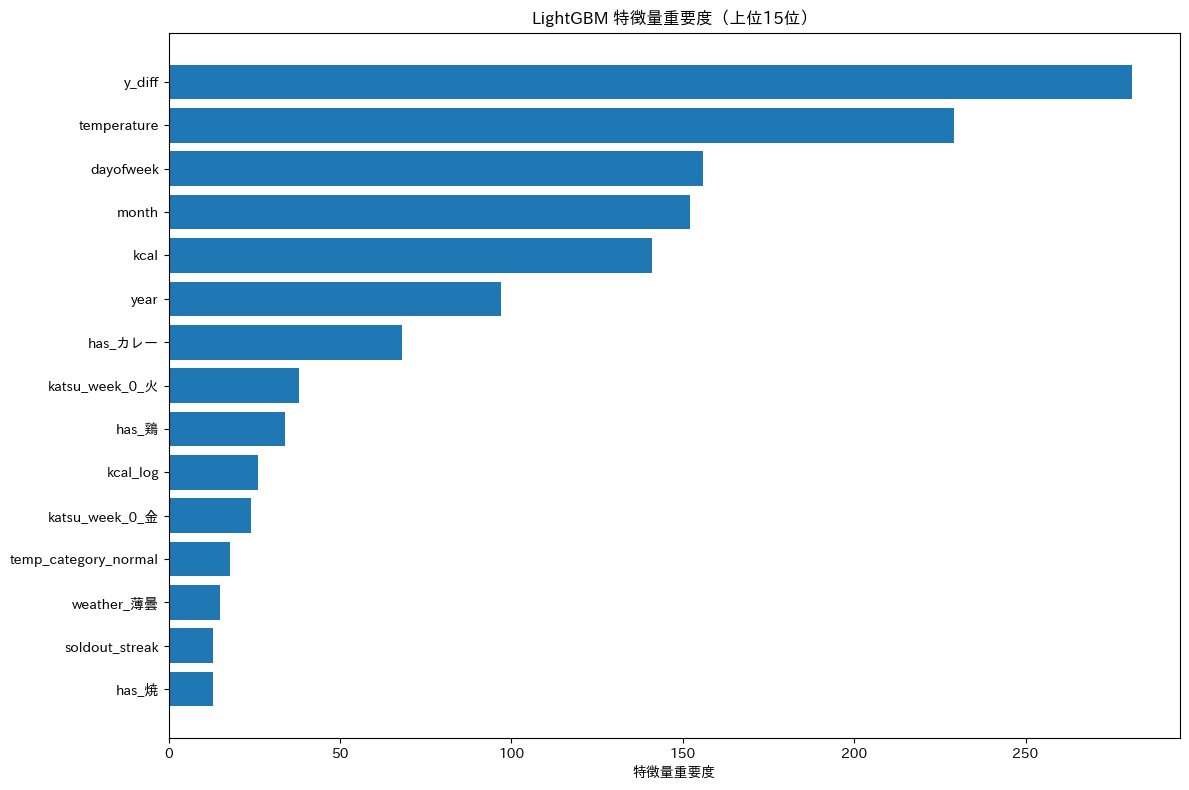

In [ ]:
# 特徴量重要度の表示
feature_importance = pd.DataFrame({
    'feature': X_train_dummy.columns,  # ダミー変数化後の特徴量名を使用
    'importance': best_lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== 特徴量重要度（上位15位）===")
print(feature_importance.head(15))

# 特徴量重要度の可視化
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('特徴量重要度')
plt.title('LightGBM 特徴量重要度（上位15位）')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


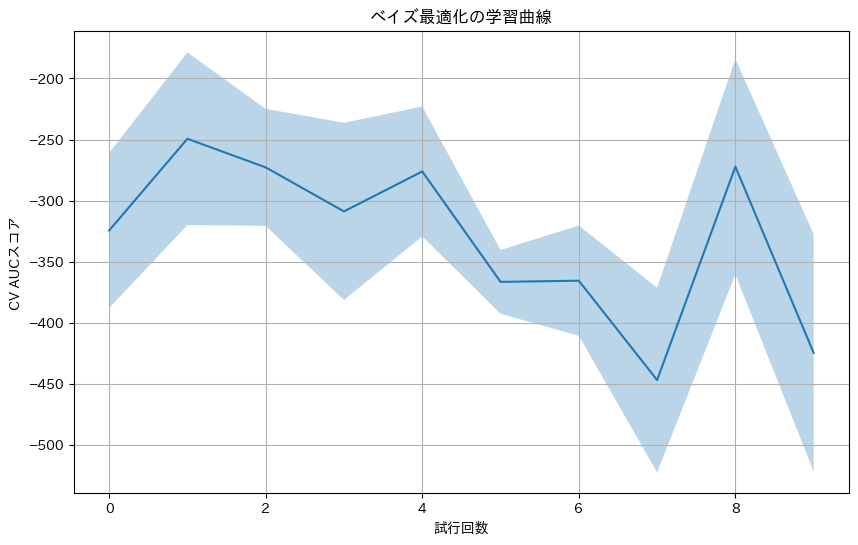

In [82]:
# ベイズ最適化の学習曲線（ベイズ最適化が成功した場合のみ表示）
if bayes_search is not None and hasattr(bayes_search, 'cv_results_'):
    plt.figure(figsize=(10, 6))
    plt.plot(bayes_search.cv_results_['mean_test_score'])
    plt.fill_between(range(len(bayes_search.cv_results_['mean_test_score'])),
                     bayes_search.cv_results_['mean_test_score'] - bayes_search.cv_results_['std_test_score'],
                     bayes_search.cv_results_['mean_test_score'] + bayes_search.cv_results_['std_test_score'],
                     alpha=0.3)
    plt.xlabel('試行回数')
    plt.ylabel('CV AUCスコア')
    plt.title('ベイズ最適化の学習曲線')
    plt.grid(True)
    plt.show()
else:
    print("ベイズ最適化が実行されなかったため、学習曲線を表示できません。")


## 7. 最終予測と提出ファイル作成


In [83]:
# 全データで再学習（最適化されたパラメータで）
print("全データでの再学習を開始...")

# 全データの欠損値補完
imputer_final = SimpleImputer(strategy='mean')
X_train_final = imputer_final.fit_transform(X_train_dummy)
X_test_final = imputer_final.transform(X_test_dummy)

# 最適化されたパラメータでモデルを再学習
final_lgb_model = LGBMRegressor(**best_params, random_state=82, verbose=-1)
final_lgb_model.fit(X_train_final, y)

print("✓ 全データでの再学習が完了しました")

# テストデータの予測
final_predictions = final_lgb_model.predict(X_test_final)

print(f"予測値の統計:")
print(f"  平均: {final_predictions.mean():.4f}")
print(f"  最小値: {final_predictions.min():.4f}")
print(f"  最大値: {final_predictions.max():.4f}")
print(f"  標準偏差: {final_predictions.std():.4f}")


全データでの再学習を開始...
✓ 全データでの再学習が完了しました
予測値の統計:
  平均: 80.1741
  最小値: 53.1358
  最大値: 114.5777
  標準偏差: 21.7024


In [84]:
# 提出ファイルの作成
import datetime
import os

# 出力ディレクトリの作成
output_dir = '/workspaces/competition/data/output/20250928'
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
output_path = f'{output_dir}/{timestamp}.csv'

# サンプル提出ファイルの読み込み（存在しない場合は作成）
sample_path = '/workspaces/competition/data/input/20250928/submit_sample.csv'
if os.path.exists(sample_path):
    submit = pd.read_csv(sample_path, header=None)
else:
    # サンプルファイルが存在しない場合は作成
    submit = pd.DataFrame({
        0: range(len(final_predictions)),
        1: final_predictions
    })

submit[1] = final_predictions
submit.to_csv(output_path, header=None, index=False)

print(f"✓ 提出ファイルが作成されました: {output_path}")
print(f"提出ファイルの形状: {submit.shape}")
print("\n提出ファイルの先頭5行:")
print(submit.head())


✓ 提出ファイルが作成されました: /workspaces/competition/data/output/20250928/20250927143252.csv
提出ファイルの形状: (40, 2)

提出ファイルの先頭5行:
   0          1
0  0  64.118693
1  1  57.980316
2  2  53.135814
3  3  63.509086
4  4  63.634577


## 8. まとめ

### 実施した改善点

1. **特徴量エンジニアリング**
   - 日付特徴量の抽出（年、月、曜日）
   - 時系列特徴量の作成（売上差分、連続売り切れ日数）
   - 気温カテゴリ化とメニュー名キーワード特徴量
   - 複合特徴量の作成（気温×天気、カツ×曜日など）
   - 数値特徴量の変換（気温の2乗項、kcalの対数変換）

2. **欠損値の適切な処理**
   - 数値型は中央値、カテゴリ型は最頻値で補完
   - データの整合性を保持

3. **LightGBM + ベイズ最適化（回帰版）**
   - 高性能な勾配ブースティング回帰アルゴリズム
   - MSE（平均二乗誤差）による効率的なハイパーパラメータ探索
   - 特徴量重要度による解釈性の向上

4. **包括的な評価（回帰指標）**
   - MSE、R²、MAEによる多角的な性能評価
   - ベースラインとの性能比較
   - 特徴量重要度の可視化

### 期待される効果

- **精度向上**: 特徴量エンジニアリングとベイズ最適化による性能向上
- **効率性**: LightGBMの高速学習とメモリ効率
- **解釈性**: 特徴量重要度によるモデルの理解
- **汎化性能**: 適切な正則化による過学習の防止
- **R MSE評価**: 回帰問題として適切な評価指標での性能測定


In [85]:
import random

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:115.0) Gecko/20100101 Firefox/115.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:115.0) Gecko/20100101 Firefox/115.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/14.1.2 Safari/605.1.15",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Edg/115.0.0.0",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 OPR/85.0.4341.72",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 OPR/85.0.4341.72",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Vivaldi/5.3.2679.55",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Vivaldi/5.3.2679.55",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Brave/1.40.107",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Brave/1.40.107",
]

random.choice(USER_AGENTS)

'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36 Vivaldi/5.3.2679.55'